# 04. Visualização e Insights

Objetivo: apresentar visualmente os principais padrões identificados na base, destacando aspectos relevantes sobre composição dos produtos, atuação das empresas e características do mercado.

As análises a seguir têm caráter exploratório e visam apoiar a interpretação dos dados para tomada de decisão.

## 1. Importação das bibliotecas e leitura das bases

Nesta etapa, são carregadas as bibliotecas de visualização e as tabelas analíticas geradas anteriormente.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

dim_produto = pd.read_csv("../data/tratado/dim_produto.csv", sep=";", encoding="utf-8-sig")
fato_produto_praga = pd.read_csv("../data/tratado/fato_produto_praga.csv", sep=";", encoding="utf-8-sig")
dim_titular = pd.read_csv("../data/tratado/dim_titular.csv", sep=";", encoding="utf-8-sig")

print("Bases carregadas com sucesso.")
print("dim_produto:", dim_produto.shape)
print("fato_produto_praga:", fato_produto_praga.shape)
print("dim_titular:", dim_titular.shape)

Bases carregadas com sucesso.
dim_produto: (4238, 11)
fato_produto_praga: (267188, 4)
dim_titular: (343, 2)


## 2. Empresas com maior número de produtos

A análise a seguir identifica os titulares de registro com maior quantidade de produtos no portfólio.

In [2]:
top_empresas = (
    dim_produto["titular_de_registro"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_empresas.columns = ["titular_de_registro", "qtd_produtos"]

display(top_empresas)

,titular_de_registro,qtd_produtos
0,Syngenta Proteção de Cultivos Ltda.  São Paul...,259
1,Nortox S.A. - Arapongas,170
2,UPL do Brasil Indústria e Comércio de Insumos ...,160
3,Adama Brasil S.A.- Londrina/PR,157
4,Sumitomo Chemical Brasil Indústria Química S.A...,151
5,CTVA Proteção de Cultivos Ltda - Barueri (Tamb...,144
6,Rainbow Defensivos Agrícolas Ltda.- Porto Aleg...,136
7,Basf S.A.  São Paulo,116
8,FMC Química do Brasil Ltda. - Campinas/SP,110
9,Bayer S.A. - São Paulo/ SP,99


C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


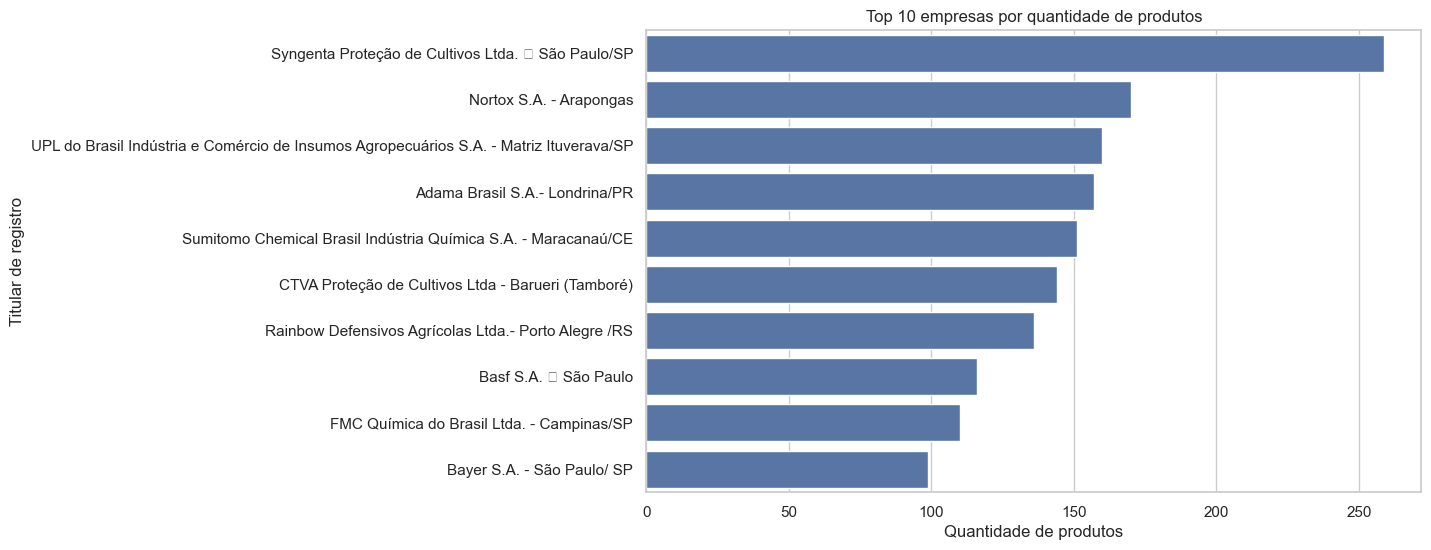

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_empresas, x="qtd_produtos", y="titular_de_registro")

plt.title("Top 10 empresas por quantidade de produtos")
plt.xlabel("Quantidade de produtos")
plt.ylabel("Titular de registro")
plt.show()

### Insight

Observa-se concentração de portfólio em algumas empresas, indicando que parte relevante dos registros está concentrada em poucos titulares.

## 3. Classes de produto mais frequentes

A distribuição por classe ajuda a entender o perfil predominante dos produtos registrados.

In [17]:
top_classes = (
    dim_produto["classe"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_classes.columns = ["classe", "qtd_produtos"]

display(top_classes)

,classe,qtd_produtos
0,Herbicida,1379
1,Fungicida,753
2,Inseticida,662
3,Inseticida Microbiológico,319
4,Acaricida/Inseticida,160
5,Fungicida microbiológico,150
6,Regulador de Crescimento,112
7,Nematicida Microbiológico,100
8,Agente Biológico de Controle/Inseticida biológico,87
9,Acaricida Microbiológico/Inseticida Microbioló...,82


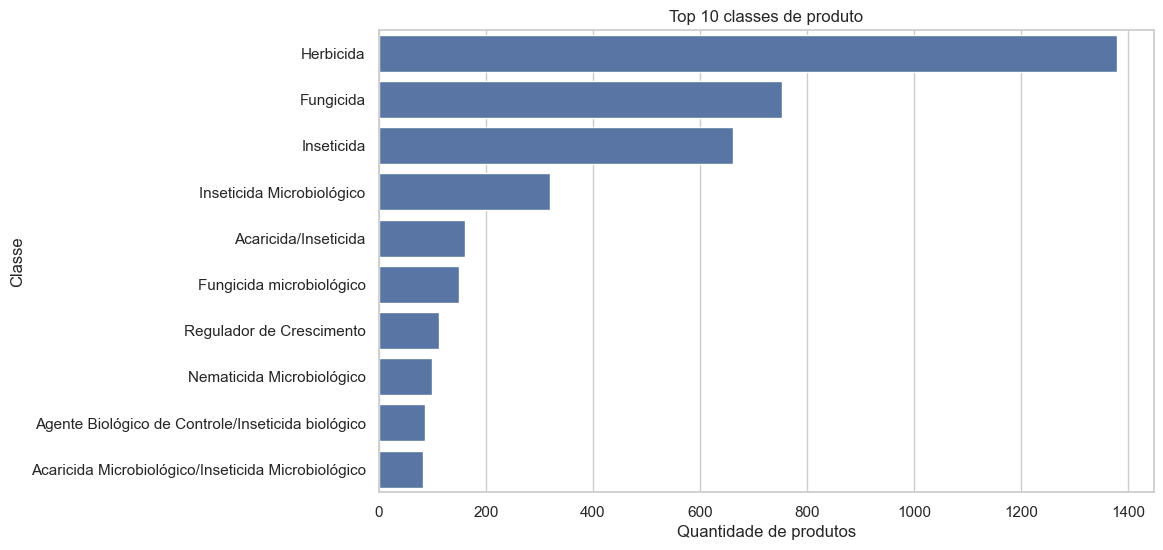

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_classes, x="qtd_produtos", y="classe")

plt.title("Top 10 classes de produto")
plt.xlabel("Quantidade de produtos")
plt.ylabel("Classe")
plt.show()

### Insight

A predominância de determinadas classes sugere concentração do mercado em alguns tipos específicos de produto.

## 4. Ingredientes ativos mais frequentes

A análise dos ingredientes ativos permite identificar os compostos ou agentes mais recorrentes entre os produtos registrados.

In [20]:
top_ingredientes = (
    dim_produto["ingrediente_ativo"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_ingredientes.columns = ["ingrediente_ativo", "qtd_produtos"]

display(top_ingredientes)

,ingrediente_ativo,qtd_produtos
0,Glufosinato - sal de amônio (homoalanina subst...,55
1,glifosato-sal de isopropilamina (glicina subst...,43
2,cletodim (oxima ciclohexanodiona) (240 g/L),34
3,sulfentrazona (triazolona) (500 g/L),32
4,clorotalonil (isoftalonitrila) (720 g/L),31
5,fipronil (pirazol) (800 g/kg),31
6,glifosato-sal de amônio (glicina substituída) ...,31
7,clorpirifós (organofosforado) (480 g/L),29
8,acetamiprido (neonicotinóide) (200 g/kg),27
9,fluazinam (fenilpiridinilamina) (500 g/L),26


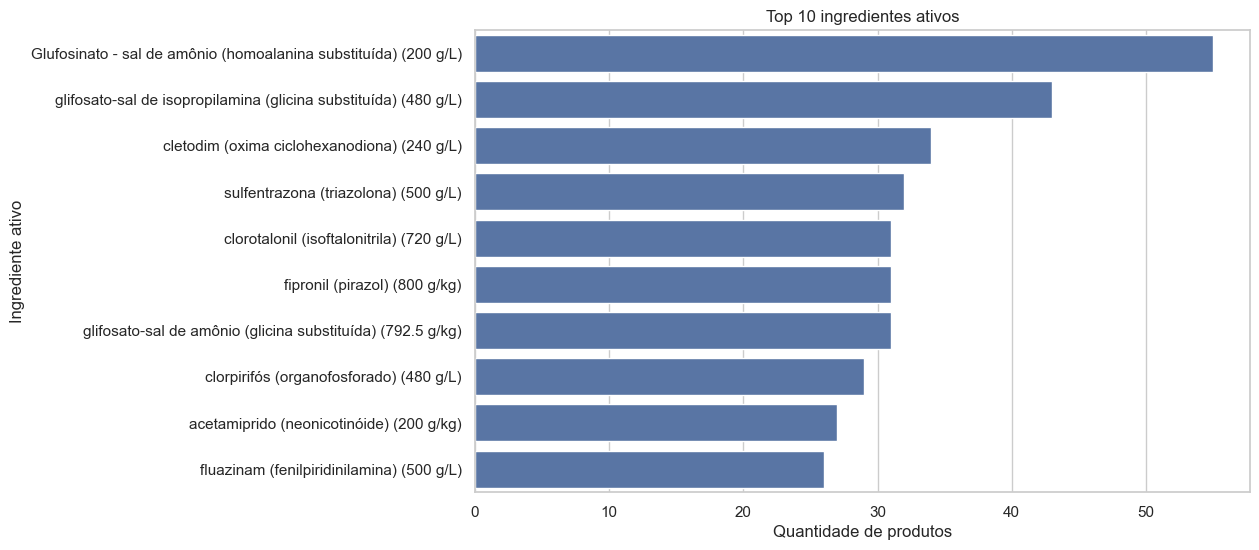

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ingredientes, x="qtd_produtos", y="ingrediente_ativo")

plt.title("Top 10 ingredientes ativos")
plt.xlabel("Quantidade de produtos")
plt.ylabel("Ingrediente ativo")
plt.show()

### Insight

A recorrência de alguns ingredientes ativos pode indicar concentração técnica do mercado e dependência de determinados compostos.

## 5. Culturas com maior número de associações

Nesta análise, são identificadas as culturas mais frequentes nas relações entre produtos e pragas.

In [ ]:
top_culturas = (
    fato_produto_praga["cultura"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_culturas.columns = ["cultura", "qtd_registros"]

display(top_culturas)   

,cultura,qtd_registros
0,Soja,20999
1,Milho,15148
2,Cana-de-açúcar,15020
3,Café,12320
4,Algodão,12044
5,Citros,11711
6,Trigo,11186
7,Pastagens,9007
8,Maçã,8710
9,Eucalipto,8564


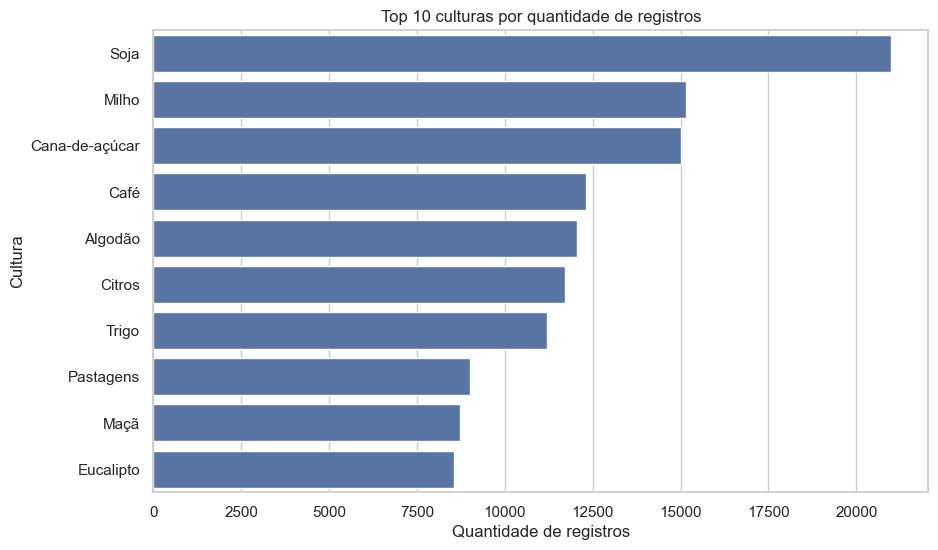

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_culturas, x="qtd_registros", y="cultura")

plt.title("Top 10 culturas por quantidade de registros")
plt.xlabel("Quantidade de registros")
plt.ylabel("Cultura")
plt.show()

### Insight

As culturas mais frequentes refletem o peso econômico de determinadas lavouras e sua relevância no mercado de produtos formulados.

## 6. Pragas mais recorrentes

A identificação das pragas mais recorrentes ajuda a entender os principais focos de aplicação dos produtos.

In [25]:
top_pragas = (
    fato_produto_praga["praga_nome_cientifico"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_pragas.columns = ["praga_nome_cientifico", "qtd_registros"]

display(top_pragas)

,praga_nome_cientifico,qtd_registros
0,Digitaria horizontalis,6468
1,Brachiaria plantaginea,6325
2,Bidens pilosa,6168
3,Eleusine indica,5958
4,Cenchrus echinatus,5413
5,Sida rhombifolia,5113
6,Euphorbia heterophylla,4665
7,Amaranthus viridis,4506
8,Portulaca oleracea,4274
9,Digitaria insularis,4263


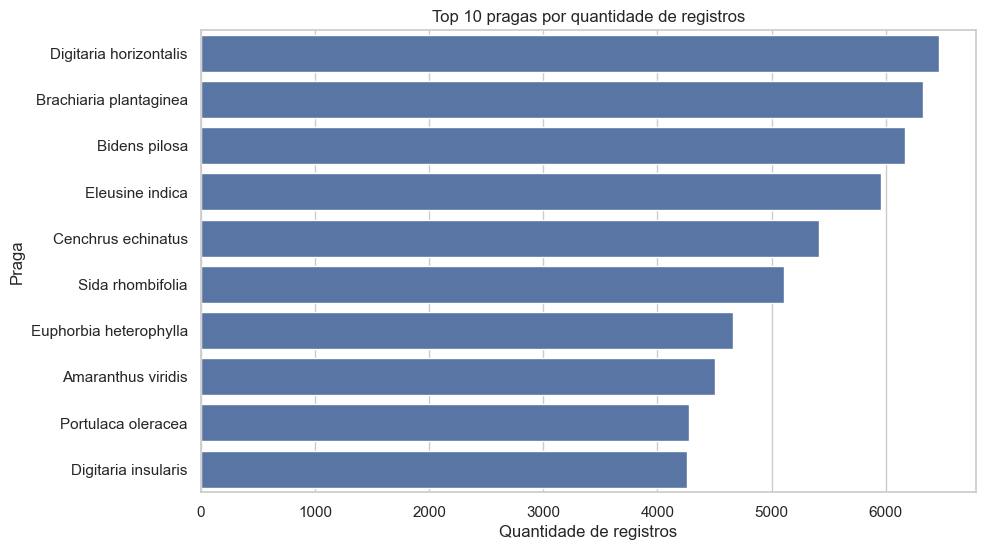

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_pragas, x="qtd_registros", y="praga_nome_cientifico")

plt.title("Top 10 pragas por quantidade de registros")
plt.xlabel("Quantidade de registros")
plt.ylabel("Praga")
plt.show()

### Insight

A concentração em algumas pragas sugere desafios recorrentes no manejo agrícola e pode orientar decisões estratégicas sobre portfólio.

## 7. Produtos orgânicos vs não orgânicos

A variável de orgânicos permite avaliar a participação relativa desse grupo dentro da base de produtos.

In [29]:
organicos_dist = (
    dim_produto["organicos"]
    .value_counts()
    .reset_index()
)

organicos_dist.columns = ["organicos", "qtd_produtos"]

display(organicos_dist)

,organicos,qtd_produtos
0,NAO,3098
1,OUTROS,693
2,SIM,447


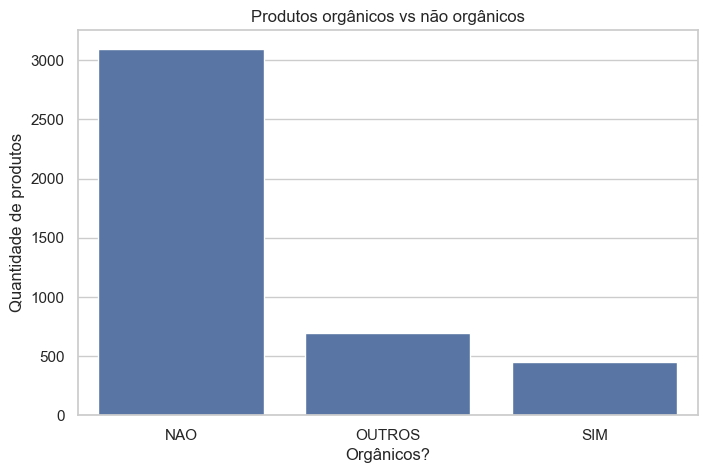

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(data=organicos_dist, x="organicos", y="qtd_produtos")

plt.title("Produtos orgânicos vs não orgânicos")
plt.xlabel("Orgânicos?")
plt.ylabel("Quantidade de produtos")
plt.show()

### Insight

A participação de produtos orgânicos na base permite avaliar a representatividade desse segmento frente ao conjunto total de produtos registrados.

## 8. Tipo de empresa (nível empresa)

Nesta análise, considera-se a dimensão de empresas, contabilizando apenas empresas únicas.

In [3]:
dist_tipo_empresa_dim = (
    dim_titular["tipo_empresa"]
    .value_counts()
    .reset_index()
)

dist_tipo_empresa_dim.columns = ["tipo_empresa", "qtd_empresas"]

display(dist_tipo_empresa_dim)

,tipo_empresa,qtd_empresas
0,Somente nacional,178
1,Com presença internacional,157
2,Não informado,5
3,Não identificado,3


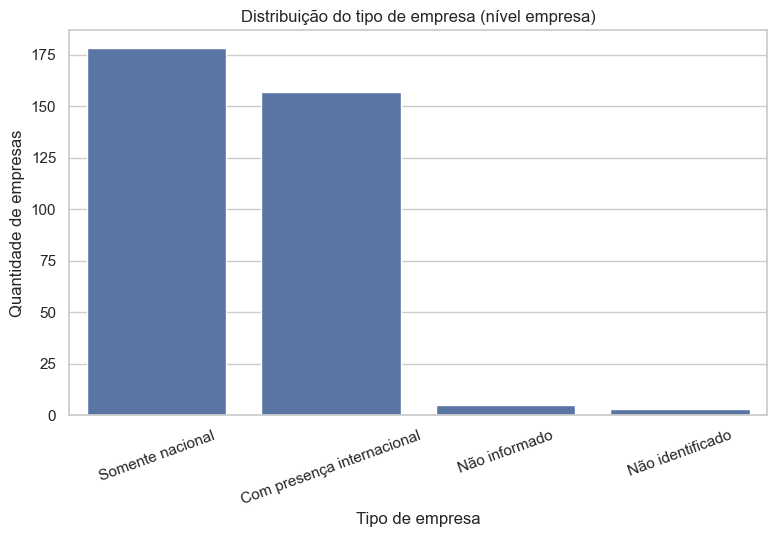

In [4]:
plt.figure(figsize=(9, 5))
sns.barplot(data=dist_tipo_empresa_dim, x="tipo_empresa", y="qtd_empresas")

plt.title("Distribuição do tipo de empresa (nível empresa)")
plt.xlabel("Tipo de empresa")
plt.ylabel("Quantidade de empresas")
plt.xticks(rotation=20)
plt.show()

### Insight

A classificação mostra predominância de empresas associadas a cadeias com presença internacional.  
Esse resultado deve ser interpretado como presença de países estrangeiros na cadeia produtiva descrita em `empresa_pais_tipo`, e não necessariamente como origem estrangeira do titular principal.

## 9. Classe toxicológica dos produtos

A distribuição das classes toxicológicas contribui para entender o perfil regulatório do portfólio analisado.

In [34]:
classe_toxico_dist = (
    dim_produto["classe_toxicologica"]
    .value_counts()
    .head(10)
    .reset_index()
)

classe_toxico_dist.columns = ["classe_toxicologica", "qtd_produtos"]

display(classe_toxico_dist)

,classe_toxicologica,qtd_produtos
0,Categoria 5  Produto Improvável de Causar Dan...,2244
1,Categoria 4  Produto Pouco Tóxico,1019
2,Não Classificado - Produto Não Classificado,484
3,Categoria 3  Produto Moderadamente Tóxico,207
4,Categoria 2  Produto Altamente Tóxico,130
5,Pouco Tóxico,46
6,NÃO DETERMINADO DEVIDO À NATUREZA DO PRODUTO,38
7,Categoria 1  Produto Extremamente Tóxico,36
8,Medianamente Tóxico,13
9,Extremamente Tóxico,12


C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


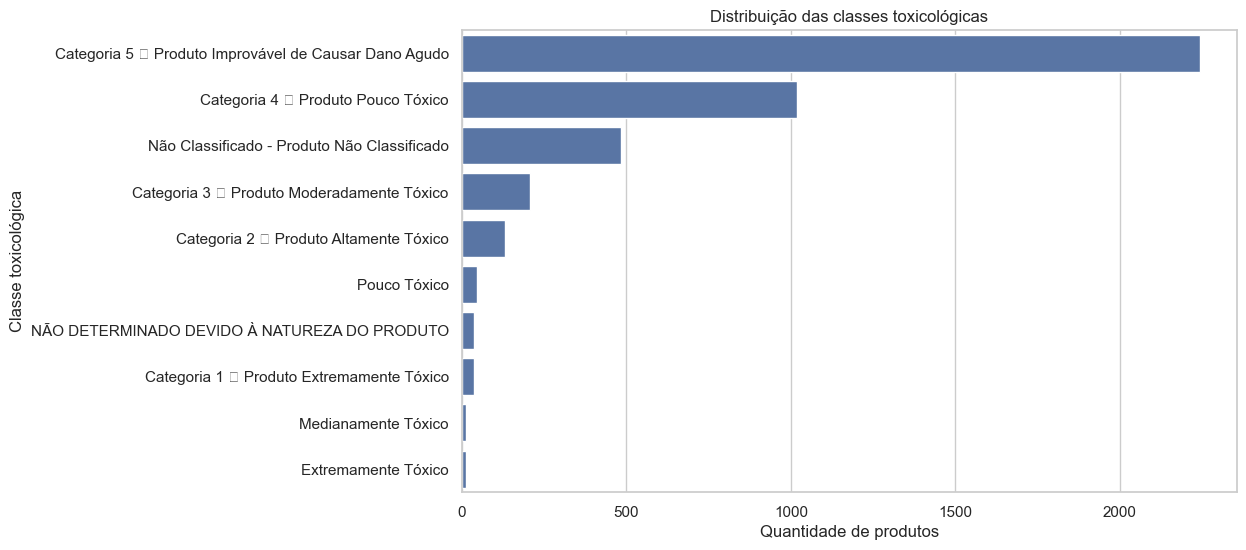

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=classe_toxico_dist, x="qtd_produtos", y="classe_toxicologica")

plt.title("Distribuição das classes toxicológicas")
plt.xlabel("Quantidade de produtos")
plt.ylabel("Classe toxicológica")
plt.show()

### Insight

A composição toxicológica da base é importante para leitura regulatória e pode ser usada para segmentação de portfólio no dashboard.

## 10. Classe ambiental dos produtos

A análise ambiental complementa a leitura regulatória, indicando o perfil de periculosidade ambiental do conjunto analisado.

In [36]:
classe_ambiental_dist = (
    dim_produto["classe_ambiental"]
    .value_counts()
    .head(10)
    .reset_index()
)

classe_ambiental_dist.columns = ["classe_ambiental", "qtd_produtos"]

display(classe_ambiental_dist)

,classe_ambiental,qtd_produtos
0,Produto Muito Perigoso ao Meio Ambiente,1713
1,Produto Perigoso ao Meio Ambiente,1371
2,Produto Pouco Perigoso ao Meio Ambiente,1049
3,Produto Altamente Perigoso ao Meio Ambiente,96
4,Produto de Baixo Risco ao Meio Ambiente,9


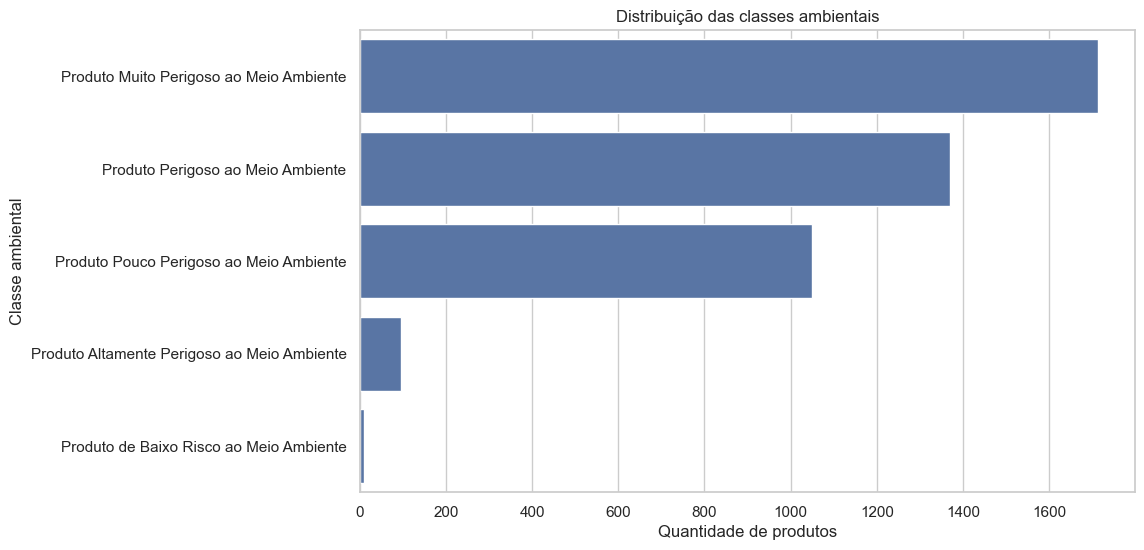

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(data=classe_ambiental_dist, x="qtd_produtos", y="classe_ambiental")

plt.title("Distribuição das classes ambientais")
plt.xlabel("Quantidade de produtos")
plt.ylabel("Classe ambiental")
plt.show()

### Insight

O perfil ambiental predominante dos produtos contribui para análises de risco e posicionamento regulatório.

## 11. Conclusões da etapa

A visualização dos dados permitiu identificar padrões relevantes sobre composição do mercado, concentração de empresas, recorrência de ingredientes ativos, foco em determinadas culturas e pragas, além da presença de cadeias produtivas com participação internacional.

Esses resultados servem de base para a construção do dashboard final no Power BI e para a apresentação executiva do case.